# Notebook 1: Generación y validación del dataset sintético

## Proyecto: Satisfacción del cliente en servicios

Este notebook corresponde al Bloque 1 del proyecto. Su propósito es generar un dataset sintético, reproducible y coherente con el dominio de satisfacción del cliente en servicios. El dataset incluye variables de perfil, comportamiento histórico, operación del servicio, variables económicas, temporales, relacionales y derivadas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 33
np.random.seed(SEED)

In [2]:
ruta_csv = "../data/processed/dataset_satisfaccion_cliente.csv"

df = pd.read_csv(ruta_csv)

df.head()

,id_cliente,id_servicio,id_region,id_sede,id_agente,id_campania,id_ticket_reciente,edad,genero,nivel_ingreso,...,tasa_resolucion_tickets,reclamos_por_mes,uso_digital_total,intensidad_contacto,ratio_pagos_atrasados,indice_problemas_servicio,indice_valor_cliente,indice_experiencia,satisfaccion_alta,score_satisfaccion
0,C000000,S5,R7,SEDE8,A14,CAM4,T0000000,42.0,M,medio,...,0.714286,0.666667,19,12,0.000000,8,460.682972,17.671459,0,3.150167
1,C000001,S8,R7,SEDE7,A98,CAM2,T0000001,47.0,F,bajo,...,0.800000,0.333333,24,6,0.000000,4,240.659655,16.330620,0,6.126267
2,C000002,S9,R4,SEDE7,A93,CAM7,T0000002,24.0,F,alto,...,0.750000,0.500000,18,7,0.000000,4,451.581853,16.876784,1,5.891257
3,C000003,S3,R7,SEDE5,A56,CAM1,T0000003,44.0,M,bajo,...,0.666667,0.333333,28,9,0.011494,3,713.861741,15.303166,0,4.586471
4,C000004,S3,R7,SEDE4,A23,CAM1,T0000004,30.0,F,bajo,...,0.800000,0.333333,22,7,0.050000,6,336.968077,16.796069,0,1.537005


In [3]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 15150
Número de columnas: 59


El dataset generado contiene 15.150 registros antes de eliminar duplicados controlados y 59 variables. Esto cumple con el requisito mínimo de 10.000 registros y supera el mínimo de 35 variables establecido en la actividad.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15150 entries, 0 to 15149
Data columns (total 59 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_cliente                     15150 non-null  str    
 1   id_servicio                    15150 non-null  str    
 2   id_region                      15150 non-null  str    
 3   id_sede                        15150 non-null  str    
 4   id_agente                      15150 non-null  str    
 5   id_campania                    15150 non-null  str    
 6   id_ticket_reciente             15150 non-null  str    
 7   edad                           15150 non-null  float64
 8   genero                         15150 non-null  str    
 9   nivel_ingreso                  14250 non-null  str    
 10  segmento_cliente               15150 non-null  str    
 11  antiguedad_meses               15150 non-null  float64
 12  tipo_cliente                   15150 non-null  str    
 1

In [5]:
tipos = df.dtypes.value_counts()
tipos

int64      23
float64    21
str        15
Name: count, dtype: int64

El dataset contiene variables numéricas, categóricas, temporales, relacionales y derivadas. Esta variedad permite representar de forma más realista el dominio de satisfacción del cliente en servicios.

| Bloque | Cantidad aproximada | Ejemplos |
|---|---:|---|
| Variables relacionales | 7 | id_cliente, id_servicio, id_region, id_sede |
| Perfil del cliente | 9 | edad, genero, nivel_ingreso, segmento_cliente |
| Comportamiento histórico | 10 | reclamos_6m, sesiones_app_mensual, tickets_abiertos_6m |
| Variables operativas | 10 | tiempo_espera_promedio_min, cumplimiento_sla, calidad_atencion_score |
| Variables económicas | 7 | valor_plan_mensual, saldo_pendiente, cargos_extra_6m |
| Variables temporales | 6 | mes_registro, trimestre, temporada_alta |
| Variables derivadas | 10 | indice_experiencia, indice_problemas_servicio, tasa_resolucion_tickets |

In [6]:
nulos = df.isnull().mean().sort_values(ascending=False) * 100
nulos[nulos > 0]

nivel_ingreso                   5.940594
ocupacion                       5.940594
tiempo_resolucion_promedio_h    5.940594
calidad_atencion_score          5.940594
saldo_pendiente                 5.940594
dtype: float64

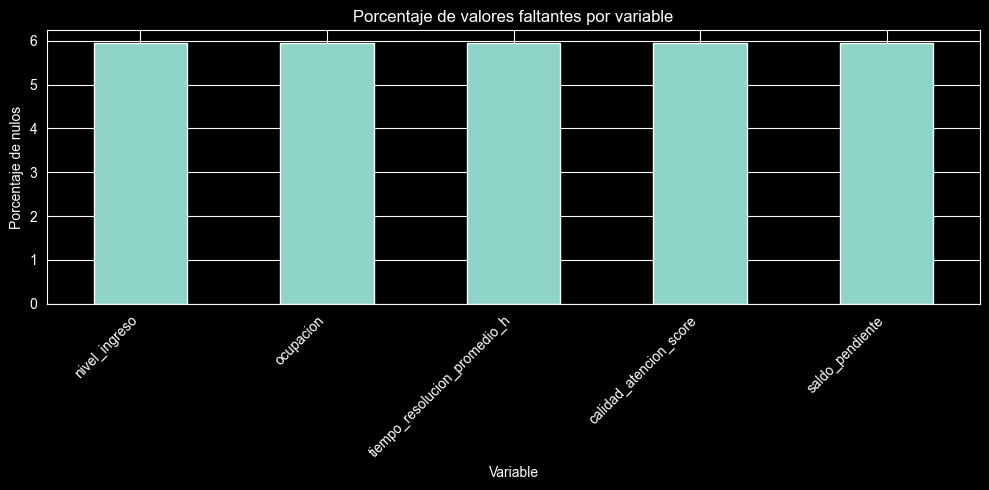

In [7]:
plt.figure(figsize=(10, 5))
nulos[nulos > 0].plot(kind="bar")
plt.title("Porcentaje de valores faltantes por variable")
plt.ylabel("Porcentaje de nulos")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Los valores faltantes fueron incorporados de forma controlada en algunas variables seleccionadas, con el objetivo de simular problemas reales de calidad de datos. El porcentaje de nulos se mantiene dentro del rango solicitado de 2% a 8%.

In [8]:
duplicados = df.duplicated().sum()
porcentaje_duplicados = df.duplicated().mean() * 100

print("Cantidad de duplicados:", duplicados)
print("Porcentaje de duplicados:", porcentaje_duplicados)

Cantidad de duplicados: 150
Porcentaje de duplicados: 0.9900990099009901


El dataset incluye duplicados controlados para representar errores de integración entre sistemas de atención, CRM y registros transaccionales. El porcentaje de duplicados se mantiene dentro del rango solicitado de 0.5% a 2%.

In [9]:
balance = df["satisfaccion_alta"].value_counts(normalize=True) * 100
balance

satisfaccion_alta
0    50.20462
1    49.79538
Name: proportion, dtype: float64

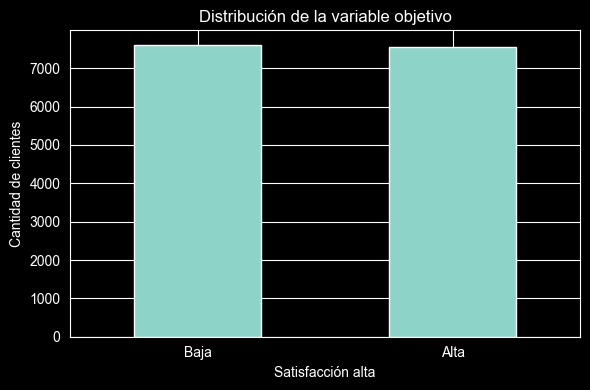

In [10]:
plt.figure(figsize=(6, 4))
df["satisfaccion_alta"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Satisfacción alta")
plt.ylabel("Cantidad de clientes")
plt.xticks([0, 1], ["Baja", "Alta"], rotation=0)
plt.tight_layout()
plt.show()

La variable objetivo `satisfaccion_alta` representa una clasificación binaria. El balance de clases permite verificar que el problema no está completamente dominado por una sola clase, lo cual favorece el entrenamiento y evaluación de modelos supervisados.

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
edad,15150.0,38.273993,11.559424,18.000000,30.000000,38.000000,46.000000,75.000000
antiguedad_meses,15150.0,35.929901,20.635279,1.000000,21.000000,32.000000,47.000000,120.000000
nivel_digitalizacion,15150.0,0.600234,0.199816,0.022422,0.457518,0.614017,0.757731,0.997178
frecuencia_uso_mensual,15150.0,17.976634,4.248625,3.000000,15.000000,18.000000,21.000000,35.000000
sesiones_app_mensual,15150.0,12.011089,3.481950,2.000000,10.000000,12.000000,14.000000,27.000000
llamadas_callcenter_3m,15150.0,2.002310,1.415728,0.000000,1.000000,2.000000,3.000000,9.000000
reclamos_6m,15150.0,1.200990,1.095270,0.000000,0.000000,1.000000,2.000000,7.000000
tickets_abiertos_6m,15150.0,2.191353,1.486629,0.000000,1.000000,2.000000,3.000000,11.000000
tickets_resueltos_6m,15150.0,1.763102,1.499285,0.000000,1.000000,2.000000,3.000000,11.000000
cancelaciones_previas,15150.0,0.073531,0.261015,0.000000,0.000000,0.000000,0.000000,1.000000


In [12]:
variables_clave = [
    "edad",
    "antiguedad_meses",
    "reclamos_6m",
    "tiempo_espera_promedio_min",
    "tiempo_resolucion_promedio_h",
    "calidad_atencion_score",
    "disponibilidad_servicio_pct",
    "valor_plan_mensual",
    "indice_problemas_servicio",
    "indice_experiencia",
    "score_satisfaccion"
]

df[variables_clave].describe().T

,count,mean,std,min,25%,50%,75%,max
edad,15150.0,38.273993,11.559424,18.000000,30.000000,38.000000,46.000000,75.000000
antiguedad_meses,15150.0,35.929901,20.635279,1.000000,21.000000,32.000000,47.000000,120.000000
reclamos_6m,15150.0,1.200990,1.095270,0.000000,0.000000,1.000000,2.000000,7.000000
tiempo_espera_promedio_min,15150.0,9.004939,8.810065,0.024576,3.956770,6.940062,11.371901,128.262918
tiempo_resolucion_promedio_h,14250.0,12.030742,8.553639,0.051637,5.721310,10.122389,16.193944,70.838337
calidad_atencion_score,14250.0,7.148290,1.596915,1.198548,6.097304,7.352281,8.401072,9.966217
disponibilidad_servicio_pct,15150.0,95.895951,2.755305,83.229307,94.002941,95.996945,98.036743,100.000000
valor_plan_mensual,15150.0,35.276675,12.790609,6.667593,26.191948,33.263257,42.045263,136.205307
indice_problemas_servicio,15150.0,2.803762,1.676717,0.000000,2.000000,3.000000,4.000000,11.000000
indice_experiencia,15150.0,15.927826,1.720909,8.588831,14.804202,16.128746,17.223560,19.827569


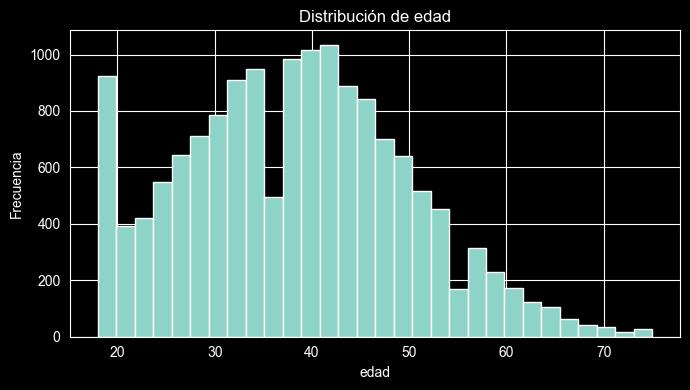

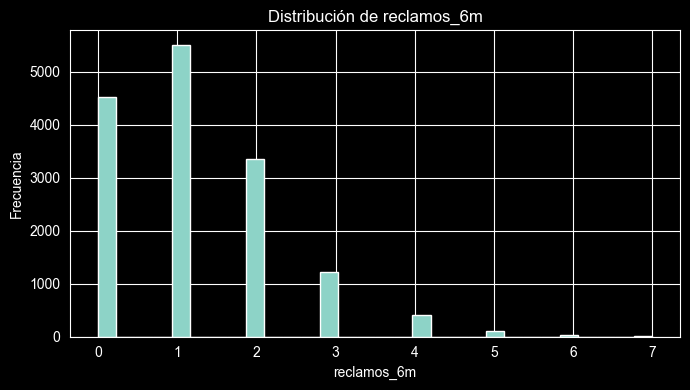

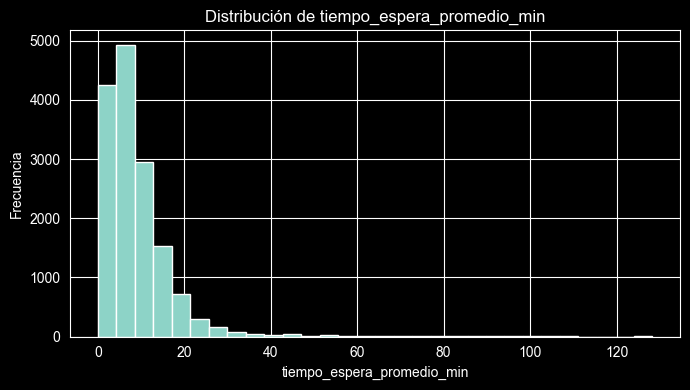

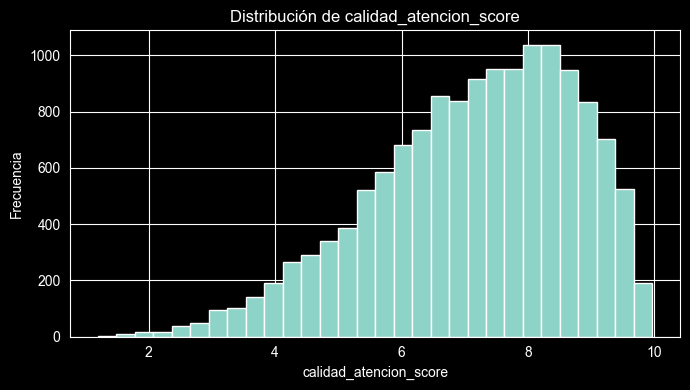

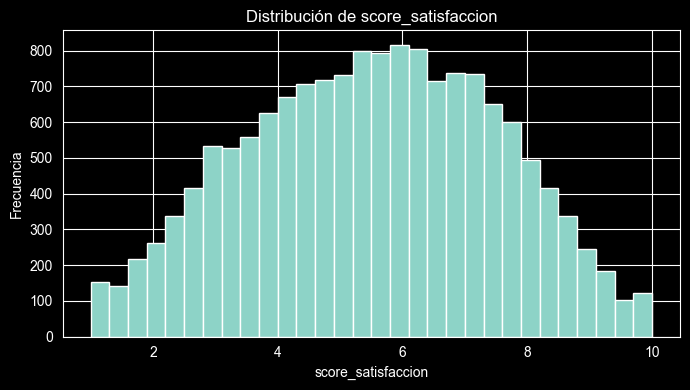

In [13]:
for col in [
    "edad",
    "reclamos_6m",
    "tiempo_espera_promedio_min",
    "calidad_atencion_score",
    "score_satisfaccion"
]:
    plt.figure(figsize=(7, 4))
    df[col].hist(bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

Las distribuciones observadas son coherentes con la naturaleza de cada variable. Las variables de conteo presentan valores discretos, las variables de tiempo presentan asimetría positiva y las variables de calificación se mantienen dentro de rangos controlados.

In [14]:
def detectar_outliers_iqr(dataframe, columna):
    q1 = dataframe[columna].quantile(0.25)
    q3 = dataframe[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = dataframe[
        (dataframe[columna] < limite_inferior) |
        (dataframe[columna] > limite_superior)
    ]

    return len(outliers), len(outliers) / len(dataframe) * 100

columnas_outliers = [
    "tiempo_espera_promedio_min",
    "tiempo_resolucion_promedio_h",
    "saldo_pendiente",
    "cargos_extra_6m",
    "reclamos_6m"
]

for col in columnas_outliers:
    cantidad, porcentaje = detectar_outliers_iqr(df, col)
    print(col, ":", cantidad, "outliers -", round(porcentaje, 2), "%")

tiempo_espera_promedio_min : 677 outliers - 4.47 %
tiempo_resolucion_promedio_h : 438 outliers - 2.89 %
saldo_pendiente : 774 outliers - 5.11 %
cargos_extra_6m : 799 outliers - 5.27 %
reclamos_6m : 25 outliers - 0.17 %


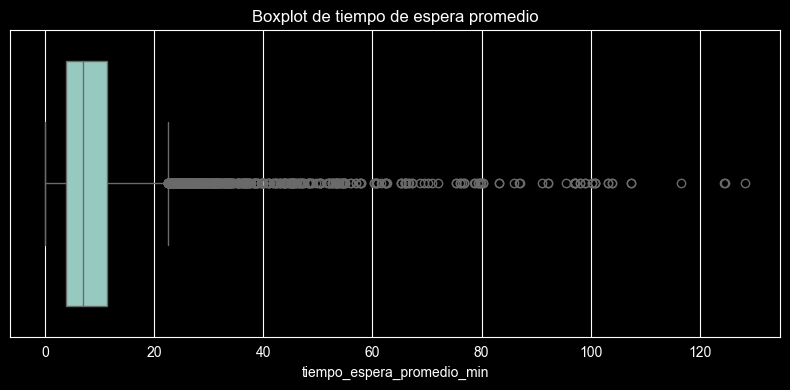

In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["tiempo_espera_promedio_min"])
plt.title("Boxplot de tiempo de espera promedio")
plt.tight_layout()
plt.show()

Los valores extremos fueron incorporados de manera controlada para simular casos atípicos reales, como tiempos de espera excesivos, saldos pendientes altos o reclamos inusuales. Estos outliers permiten evaluar la robustez del proceso de limpieza y modelado.

In [16]:
corr_objetivo = (
    df.corr(numeric_only=True)["satisfaccion_alta"]
    .sort_values(ascending=False)
)

corr_objetivo

satisfaccion_alta               1.000000
score_satisfaccion              0.385773
indice_experiencia              0.150391
resolucion_primer_contacto      0.127575
calidad_atencion_score          0.122371
cumplimiento_sla                0.100412
disponibilidad_servicio_pct     0.028667
uso_chatbot_mensual             0.017921
edad                            0.013545
meses_desde_ultimo_reclamo      0.010266
mes_registro                    0.009345
temporada_alta                  0.008159
trimestre                       0.007316
uso_digital_total               0.006275
sesiones_app_mensual            0.005549
nivel_digitalizacion            0.004352
cargos_extra_6m                 0.003896
cambios_plan_12m                0.001536
saldo_pendiente                 0.001118
tiempo_primera_respuesta_min   -0.000260
cancelaciones_previas          -0.000364
es_fin_de_semana               -0.001244
antiguedad_meses               -0.001562
frecuencia_uso_mensual         -0.002757
descuentos_recib

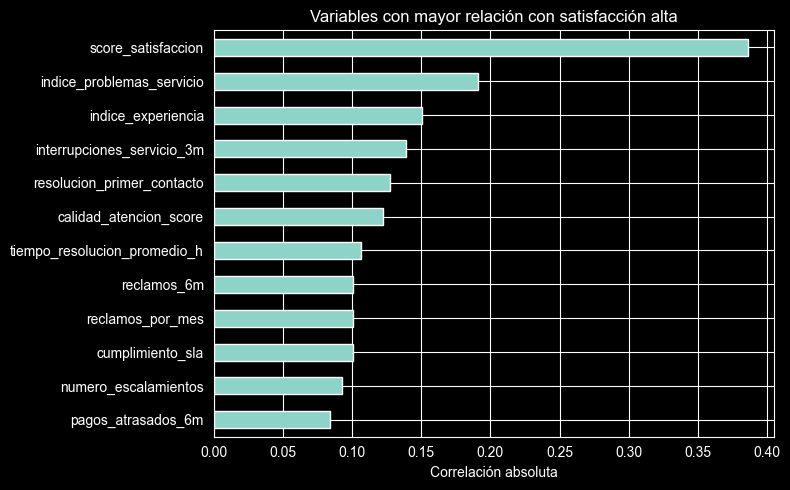

In [17]:
top_corr = corr_objetivo.drop("satisfaccion_alta").abs().sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 5))
top_corr.sort_values().plot(kind="barh")
plt.title("Variables con mayor relación con satisfacción alta")
plt.xlabel("Correlación absoluta")
plt.tight_layout()
plt.show()

Las correlaciones permiten comprobar que la variable objetivo no fue generada de forma completamente aleatoria. Variables como calidad de atención, reclamos, tiempos de atención, cumplimiento SLA, interrupciones y resolución en primer contacto presentan relación con la satisfacción del cliente, lo cual valida la lógica de simulación.

In [18]:
df.groupby("satisfaccion_alta")[
    [
        "reclamos_6m",
        "tiempo_espera_promedio_min",
        "tiempo_resolucion_promedio_h",
        "calidad_atencion_score",
        "disponibilidad_servicio_pct",
        "indice_problemas_servicio",
        "indice_experiencia"
    ]
].mean()

,reclamos_6m,tiempo_espera_promedio_min,tiempo_resolucion_promedio_h,calidad_atencion_score,disponibilidad_servicio_pct,indice_problemas_servicio,indice_experiencia
satisfaccion_alta,,,,,,,
0,1.310939,9.567193,12.934843,6.954138,95.817290,3.123192,15.670082
1,1.090138,8.438063,11.114890,7.344965,95.975258,2.481707,16.187689


La comparación de promedios entre clientes con satisfacción alta y baja permite verificar que existen diferencias coherentes entre ambos grupos. Los clientes satisfechos deberían presentar mejores indicadores de experiencia, menor número de reclamos y menor índice de problemas.

In [19]:
df.to_csv("../data/processed/dataset_satisfaccion_cliente.csv", index=False)
df.to_parquet("../data/processed/dataset_satisfaccion_cliente.parquet", index=False)

El dataset sintético fue generado y validado correctamente. Se verificó el cumplimiento de los requisitos de tamaño, número de variables, presencia controlada de nulos, outliers y duplicados, balance de clases y coherencia entre variables. Por tanto, el dataset está listo para ser utilizado en el Bloque 2 con Spark MLlib.